# Tesla Stock Price Prediction using SimpleRNN and LSTM

**Domain:** Financial Services

**Problem Statement:**  
Develop deep learning models (SimpleRNN and LSTM) to predict Tesla's
closing stock price 1-day, 5-day and 10-day ahead, and compare their
performance.

## Project Objectives

- Analyze and preprocess Tesla stock price data.
- Perform exploratory data analysis and visualization.
- Build SimpleRNN and LSTM models.
- Predict 1-day, 5-day and 10-day stock prices.
- Evaluate models using MSE, RMSE and MAE.
- Tune LSTM hyperparameters using GridSearchCV.
- Compare SimpleRNN and LSTM performance.
- Analyze limitations and future improvements.

## Section 1: Import Libraries & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

plt.style.use('seaborn-v0_8-darkgrid')
tf.random.set_seed(42)
np.random.seed(42)

print("All libraries imported successfully")

All libraries imported successfully


## Section 2: Load Dataset

In [2]:
candidate_paths = ["TSLA.csv", "/mnt/user-data/uploads/TSLA.csv"]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])

df = pd.read_csv(csv_path)
print(f"Dataset loaded successfully from: {csv_path}")
df.head()

Dataset loaded successfully from: TSLA.csv


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


## Section 3: Data Understanding

In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (2416, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


## Section 4: Data Cleaning

In [6]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Records: 0


In [7]:
# Demonstrate the missing-value strategy on a simulated copy (real data has no gaps)
rng = np.random.RandomState(42)
demo = df.copy()
sim_idx = rng.choice(demo.index[20:-20], size=15, replace=False)
demo.loc[sim_idx, 'Adj Close'] = np.nan
print("Simulated NaNs:", demo['Adj Close'].isnull().sum())

demo['Adj Close'] = demo['Adj Close'].ffill().interpolate(method='linear')
print("After ffill + interpolate:", demo['Adj Close'].isnull().sum())

Simulated NaNs: 15
After ffill + interpolate: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(df["Date"].dtype)

datetime64[ns]


In [9]:
df.set_index("Date", inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## Section 5: Exploratory Data Analysis (EDA)

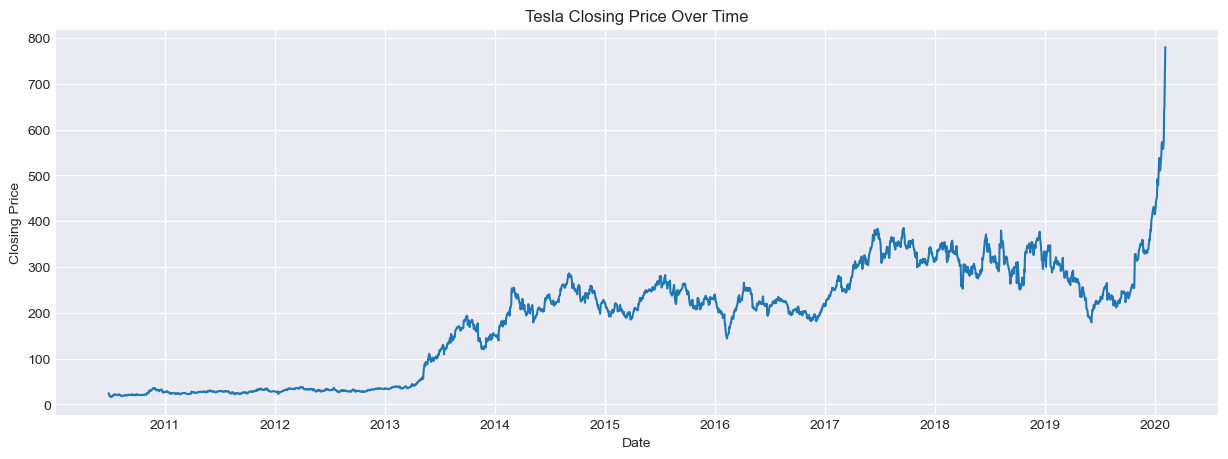

In [10]:
plt.figure(figsize=(15,5))
plt.plot(df["Close"])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date"); plt.ylabel("Closing Price"); plt.grid(True)
plt.show()

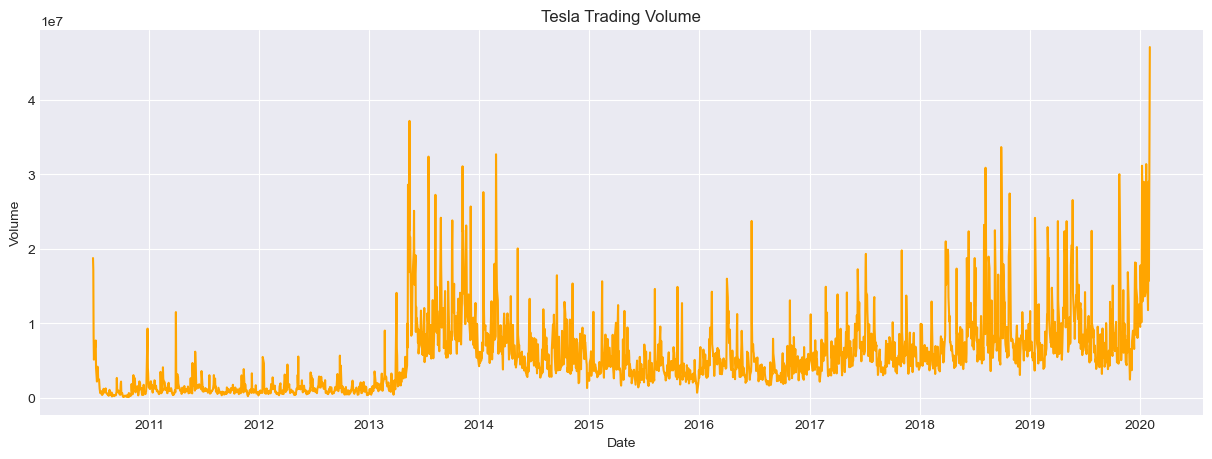

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df["Volume"], color="orange")
plt.title("Tesla Trading Volume")
plt.xlabel("Date"); plt.ylabel("Volume"); plt.grid(True)
plt.show()

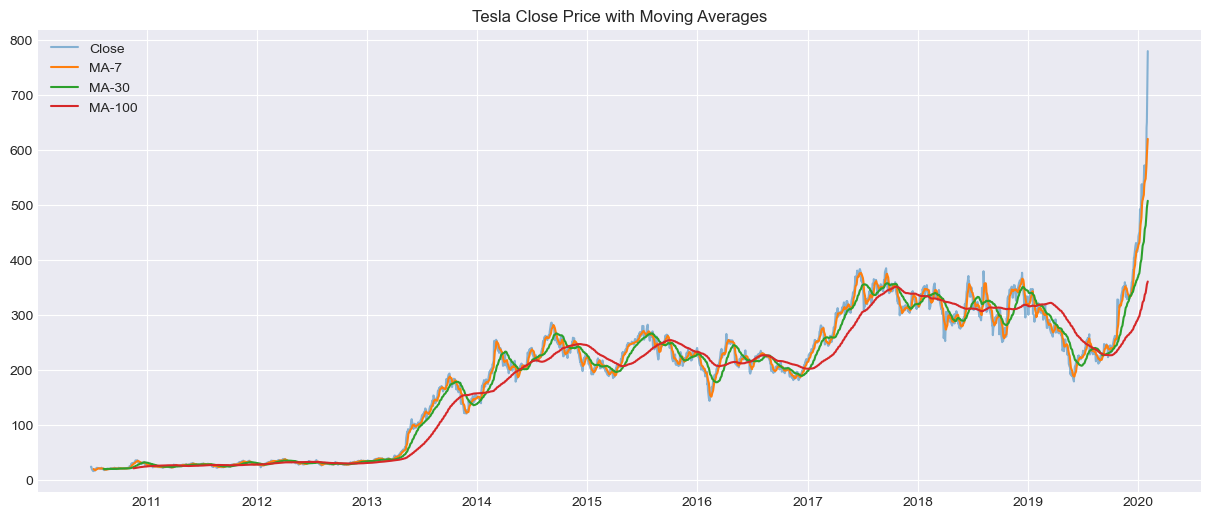

In [12]:
df["MA7"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["MA100"] = df["Close"].rolling(100).mean()

plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Close", alpha=0.5)
plt.plot(df["MA7"], label="MA-7")
plt.plot(df["MA30"], label="MA-30")
plt.plot(df["MA100"], label="MA-100")
plt.title("Tesla Close Price with Moving Averages")
plt.legend(); plt.show()


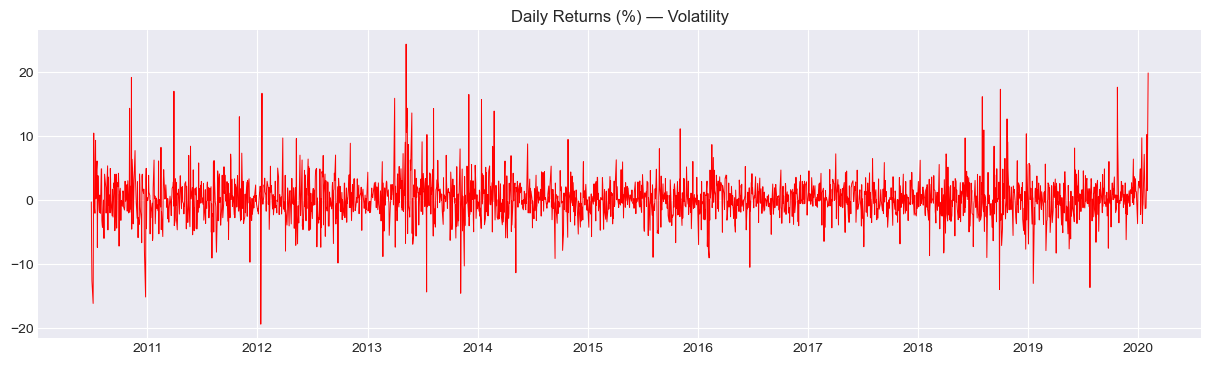

In [13]:
df["Daily_Return"] = df["Close"].pct_change() * 100
plt.figure(figsize=(15,4))
plt.plot(df["Daily_Return"], color="red", linewidth=0.7)
plt.title("Daily Returns (%) — Volatility")
plt.show()


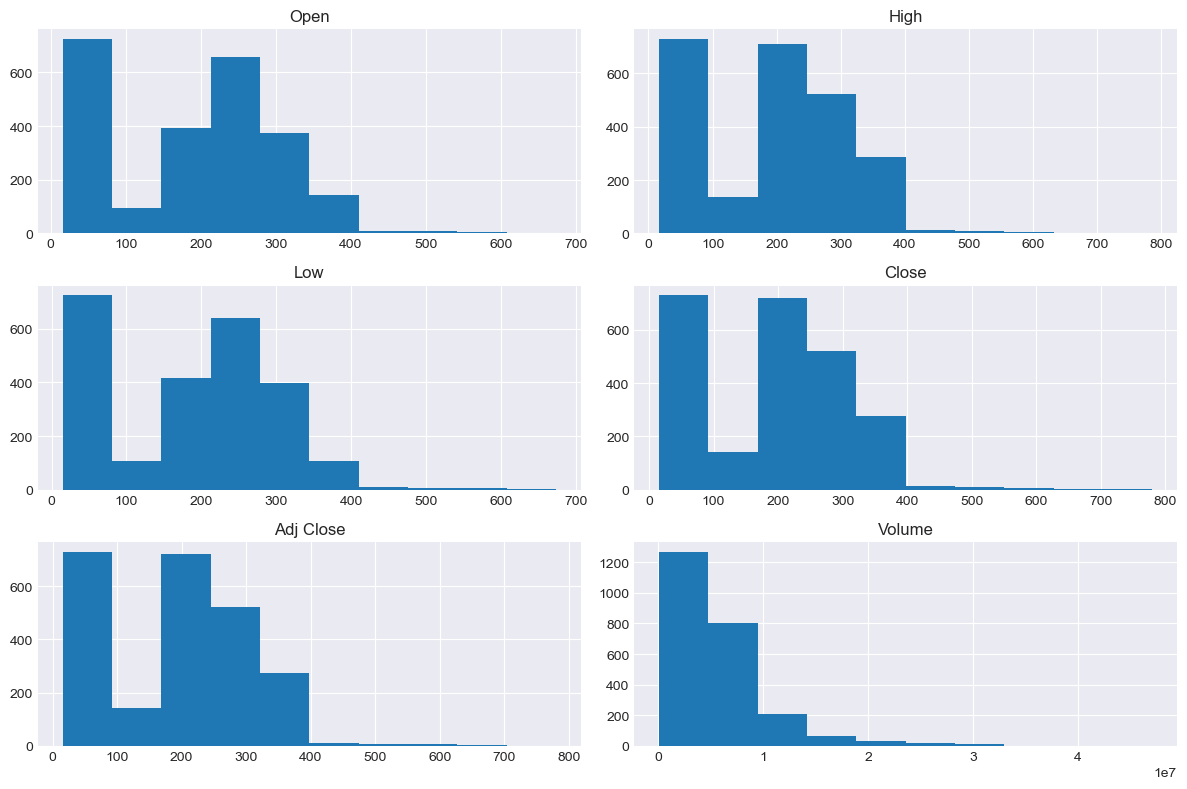

In [14]:
df[["Open","High","Low","Close","Adj Close","Volume"]].hist(figsize=(12,8))
plt.tight_layout(); plt.show()

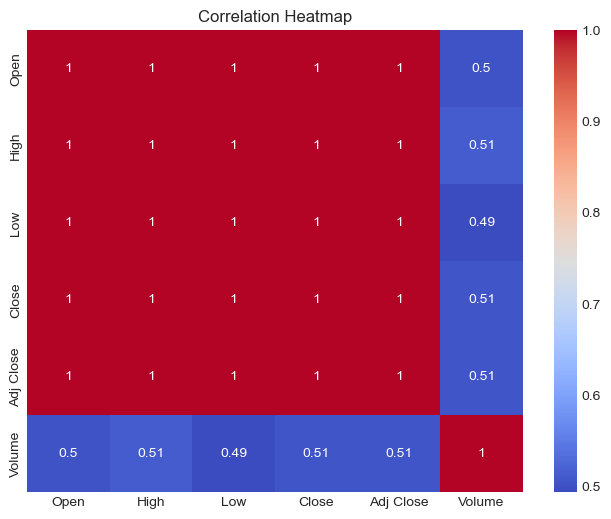

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open","High","Low","Close","Adj Close","Volume"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

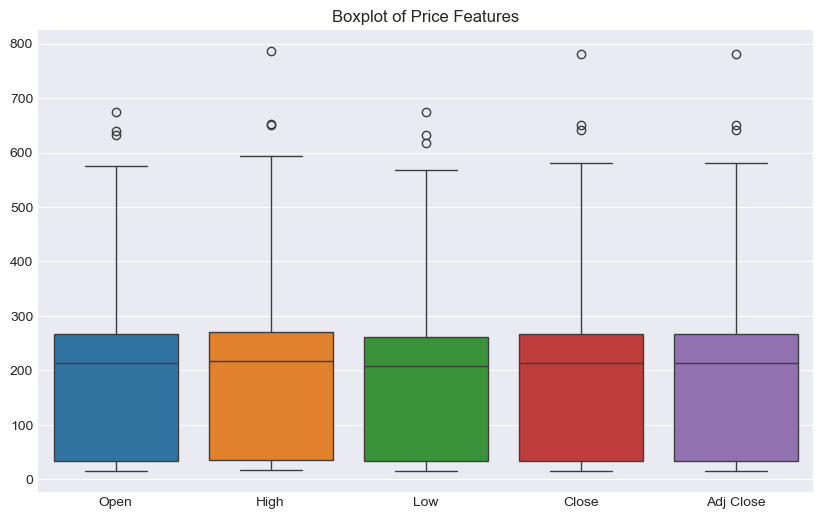

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["Open","High","Low","Close","Adj Close"]])
plt.title("Boxplot of Price Features")
plt.show()

## Section 6: Feature Engineering & Target Selection

In [17]:
data = df[["Adj Close"]]
print("Shape of selected data:", data.shape)
data.head()

Shape of selected data: (2416, 1)


,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


## Section 7: Data Scaling

In [18]:
SPLIT_RATIO = 0.8
split_point = int(len(data) * SPLIT_RATIO)
print("Split date:", df.index[split_point].date())

train_raw = data.values[:split_point]
test_raw  = data.values[split_point:]

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_raw)                      # fit on TRAIN ONLY
train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print("Train size:", len(train_raw), " Test size:", len(test_raw))

Split date: 2018-03-02
Train size: 1932  Test size: 484


## Section 8: Time-Series Sequence Creation (per forecast horizon)

In [19]:
WINDOW = 60
HORIZONS = [1, 5, 10]

def create_sequences(scaled_series, window, horizon):
    X, y = [], []
    for i in range(len(scaled_series) - window - horizon + 1):
        X.append(scaled_series[i:i+window, 0])
        y.append(scaled_series[i+window+horizon-1, 0])
    X = np.array(X); y = np.array(y)
    return X.reshape(X.shape[0], X.shape[1], 1), y

full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

datasets = {}
for h in HORIZONS:
    X_all, y_all = create_sequences(full_scaled, WINDOW, h)
    n_test = max(len(test_scaled) - h + 1, 1)
    X_train, y_train = X_all[:-n_test], y_all[:-n_test]
    X_test,  y_test  = X_all[-n_test:], y_all[-n_test:]
    datasets[h] = dict(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"Horizon {h}d -> X_train {X_train.shape}, X_test {X_test.shape}")

Horizon 1d -> X_train (1872, 60, 1), X_test (484, 60, 1)
Horizon 5d -> X_train (1872, 60, 1), X_test (480, 60, 1)
Horizon 10d -> X_train (1872, 60, 1), X_test (475, 60, 1)


## Section 9: Train-Test Split

In [20]:
summary = pd.DataFrame([
    {"Horizon": h, "X_train": str(datasets[h]['X_train'].shape),
     "X_test": str(datasets[h]['X_test'].shape)} for h in HORIZONS
])
summary

,Horizon,X_train,X_test
0,1,"(1872, 60, 1)","(484, 60, 1)"
1,5,"(1872, 60, 1)","(480, 60, 1)"
2,10,"(1872, 60, 1)","(475, 60, 1)"


## Section 10: Model Architectures — SimpleRNN & LSTM

In [21]:
def build_simplernn(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        SimpleRNN(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

def build_lstm(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        LSTM(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

build_simplernn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
build_lstm().summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## Section 11: Training — SimpleRNN & LSTM for all 3 horizons

In [23]:
results = {}
histories = {}

for h in HORIZONS:
    Xtr, ytr = datasets[h]['X_train'], datasets[h]['y_train']
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']

    for arch, builder in [("SimpleRNN", build_simplernn), ("LSTM", build_lstm)]:
        print(f"\n{'='*55}\nTraining {arch} | horizon={h}d\n{'='*55}")
        model = builder(WINDOW)
        ckpt = f"best_{arch}_h{h}.keras"
        cbs = [
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True)
        ]
        hist = model.fit(Xtr, ytr, validation_split=0.1, epochs=50,
                          batch_size=32, callbacks=cbs, verbose=0)
        test_mse_scaled = model.evaluate(Xte, yte, verbose=0)
        print(f"{arch} h={h}d -> epochs run: {len(hist.history['loss'])}, "
              f"final val_loss: {hist.history['val_loss'][-1]:.6f}, "
              f"test loss (scaled): {test_mse_scaled:.6f}")
        key = f"{arch}_h{h}"
        results[key] = dict(model_path=ckpt, arch=arch, horizon=h)
        histories[key] = hist.history

print("\nAll 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).")


Training SimpleRNN | horizon=1d
SimpleRNN h=1d -> epochs run: 10, final val_loss: 0.006130, test loss (scaled): 0.012985

Training LSTM | horizon=1d
LSTM h=1d -> epochs run: 29, final val_loss: 0.002114, test loss (scaled): 0.004466

Training SimpleRNN | horizon=5d
SimpleRNN h=5d -> epochs run: 17, final val_loss: 0.004417, test loss (scaled): 0.009222

Training LSTM | horizon=5d
LSTM h=5d -> epochs run: 19, final val_loss: 0.004465, test loss (scaled): 0.009471

Training SimpleRNN | horizon=10d
SimpleRNN h=10d -> epochs run: 28, final val_loss: 0.003858, test loss (scaled): 0.012288

Training LSTM | horizon=10d
LSTM h=10d -> epochs run: 9, final val_loss: 0.004142, test loss (scaled): 0.016916

All 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).


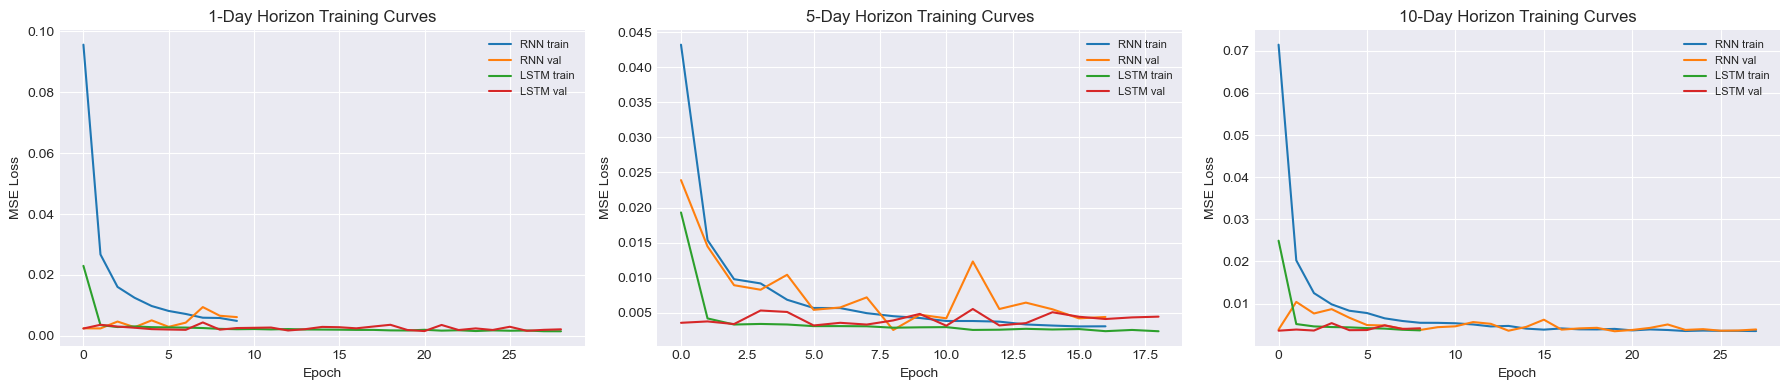

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, h in zip(axes, HORIZONS):
    ax.plot(histories[f"SimpleRNN_h{h}"]["loss"], label="RNN train")
    ax.plot(histories[f"SimpleRNN_h{h}"]["val_loss"], label="RNN val")
    ax.plot(histories[f"LSTM_h{h}"]["loss"], label="LSTM train")
    ax.plot(histories[f"LSTM_h{h}"]["val_loss"], label="LSTM val")
    ax.set_title(f"{h}-Day Horizon Training Curves")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Section 12: Evaluation — MSE / RMSE / MAE per model per horizon

In [25]:
eval_rows = []
predictions_store = {}
for h in HORIZONS:
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']
    y_actual = scaler.inverse_transform(yte.reshape(-1,1))
    for arch in ["SimpleRNN", "LSTM"]:
        key = f"{arch}_h{h}"
        model = load_model(results[key]['model_path'])
        pred_scaled = model.predict(Xte, verbose=0)
        pred = scaler.inverse_transform(pred_scaled)
        mse = mean_squared_error(y_actual, pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_actual, pred)
        r2 = r2_score(y_actual, pred)          
        eval_rows.append({"Model": arch, "Horizon (days)": h, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2 Score": r2})
        predictions_store[key] = dict(actual=y_actual, pred=pred)
comparison = pd.DataFrame(eval_rows).sort_values(["Horizon (days)", "Model"]).reset_index(drop=True)
comparison

,Model,Horizon (days),MSE,RMSE,MAE,R2 Score
0,LSTM,1,608.768277,24.673230,16.140820,0.881995
1,SimpleRNN,1,1769.979188,42.071121,26.739000,0.656903
2,LSTM,5,1290.940592,35.929662,24.771032,0.751483
3,SimpleRNN,5,1257.050246,35.454904,22.486980,0.758007
4,LSTM,10,2305.738546,48.018106,33.667320,0.559817
5,SimpleRNN,10,1674.979409,40.926512,28.818479,0.680234


## Section 13: Actual vs Predicted — visualizations per horizon

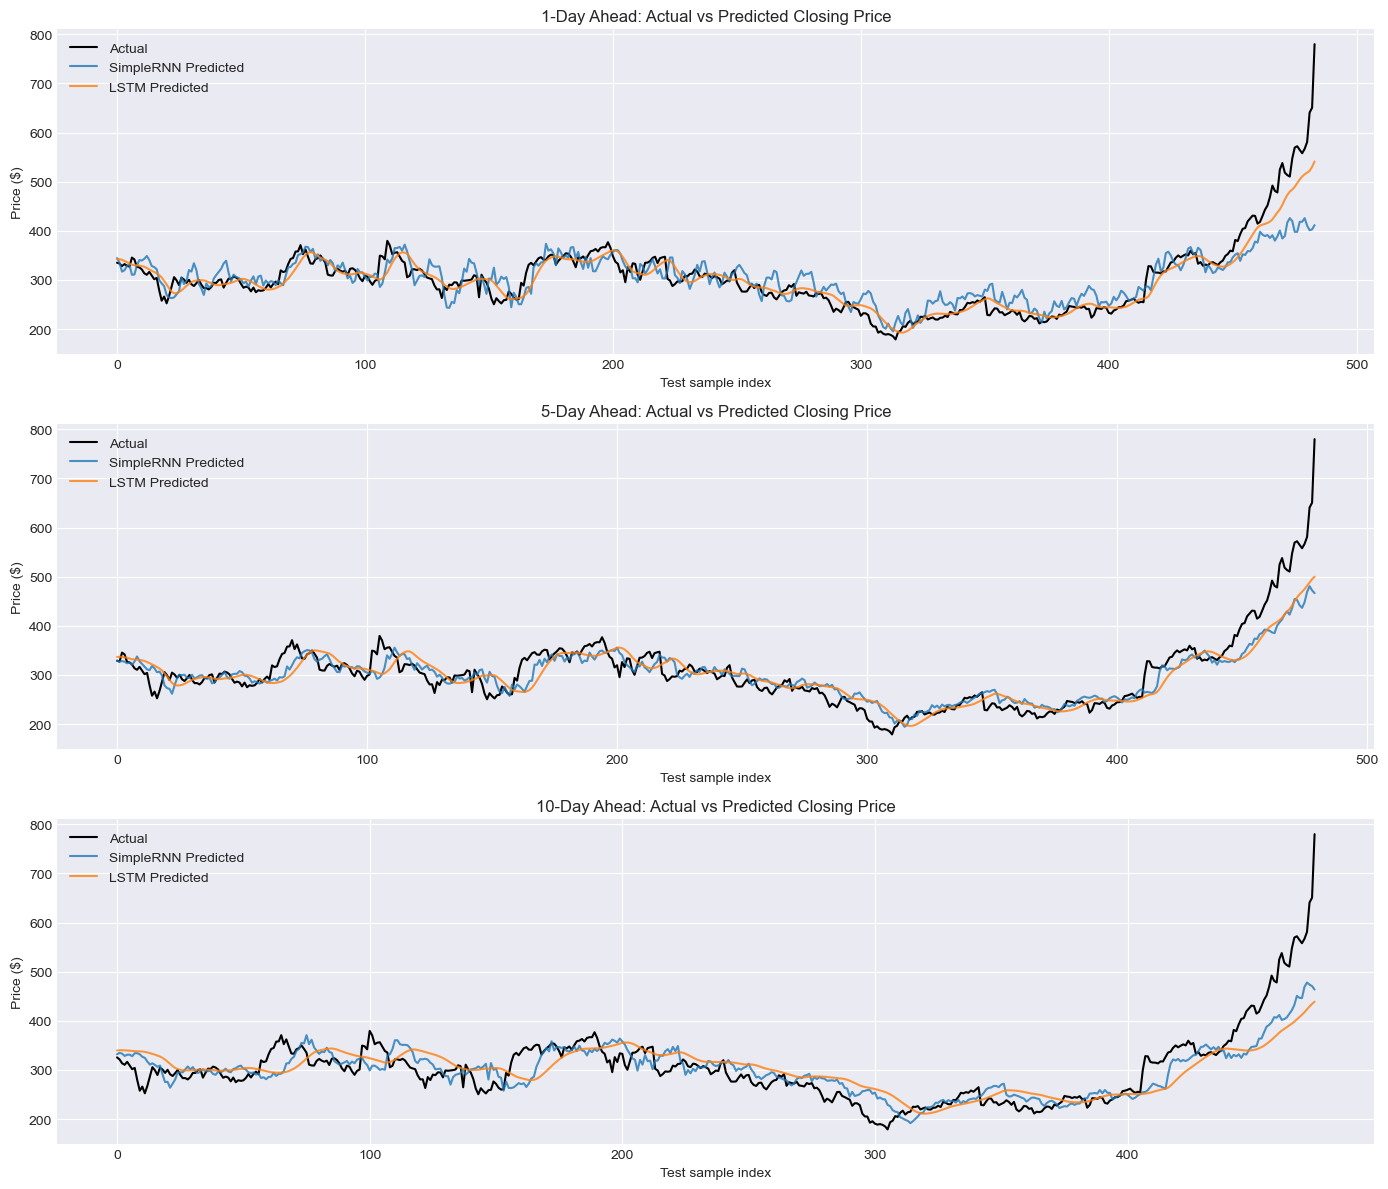

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for ax, h in zip(axes, HORIZONS):
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["actual"], label="Actual", color="black", linewidth=1.5)
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["pred"], label="SimpleRNN Predicted", alpha=0.8)
    ax.plot(predictions_store[f"LSTM_h{h}"]["pred"], label="LSTM Predicted", alpha=0.8)
    ax.set_title(f"{h}-Day Ahead: Actual vs Predicted Closing Price")
    ax.set_xlabel("Test sample index"); ax.set_ylabel("Price ($)"); ax.legend()
plt.tight_layout(); plt.show()


## Section 14: Hyperparameter Tuning with GridSearchCV

In [27]:
# ============================================================
# Section 14: Hyperparameter Tuning with GridSearchCV
# SimpleRNN & LSTM | 1-day, 5-day, 10-day
# ============================================================

from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV


# ------------------------------------------------------------
# Wrapper functions for GridSearchCV
# ------------------------------------------------------------

def build_lstm_for_grid(units=64, dropout=0.2, learning_rate=0.001):
    return build_lstm(
        WINDOW,
        units=units,
        dropout=dropout,
        learning_rate=learning_rate
    )


def build_simplernn_for_grid(units=64, dropout=0.2, learning_rate=0.001):
    return build_simplernn(
        WINDOW,
        units=units,
        dropout=dropout,
        learning_rate=learning_rate
    )


# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------

param_grid = {
    "model__units": [32, 64],
    "model__dropout": [0.2, 0.3],
    "model__learning_rate": [0.001, 0.005],
}


# ------------------------------------------------------------
# Models to tune
# ------------------------------------------------------------

builders = {
    "LSTM": build_lstm_for_grid,
    "SimpleRNN": build_simplernn_for_grid
}


# ------------------------------------------------------------
# Store tuning results
# ------------------------------------------------------------

tuning_results = {}


# ------------------------------------------------------------
# GridSearchCV for both models and all horizons
# ------------------------------------------------------------

for arch, build_fn in builders.items():

    for h in HORIZONS:

        print(f"\n{'='*60}")
        print(f"GridSearchCV: {arch} | Horizon = {h} days")
        print(f"{'='*60}")

        Xtr = datasets[h]["X_train"]
        ytr = datasets[h]["y_train"]

        Xte = datasets[h]["X_test"]
        yte = datasets[h]["y_test"]


        # Keras model wrapper
        reg = KerasRegressor(
            model=build_fn,
            verbose=0,
            epochs=8,
            batch_size=32
        )


        # GridSearchCV
        grid = GridSearchCV(
            estimator=reg,
            param_grid=param_grid,
            scoring="neg_mean_squared_error",
            cv=2,
            n_jobs=1
        )


        # Run GridSearch
        grid_result = grid.fit(Xtr, ytr)


        # Best parameters
        best_params = {
            k.replace("model__", ""): v
            for k, v in grid_result.best_params_.items()
        }


        print("Best Parameters:", best_params)

        print(
            "Best CV Score (negative MSE):",
            grid_result.best_score_
        )


        # ----------------------------------------------------
        # Retrain model using best parameters
        # ----------------------------------------------------

        if arch == "LSTM":
            tuned_model = build_lstm(
                WINDOW,
                **best_params
            )
        else:
            tuned_model = build_simplernn(
                WINDOW,
                **best_params
            )


        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=8,
                restore_best_weights=True
            ),

            ModelCheckpoint(
                f"best_{arch}_h{h}_tuned.keras",
                monitor="val_loss",
                save_best_only=True
            )
        ]


        tuned_model.fit(
            Xtr,
            ytr,
            validation_split=0.1,
            epochs=50,
            batch_size=32,
            callbacks=callbacks,
            verbose=0
        )


        # ----------------------------------------------------
        # Prediction on held-out test data
        # ----------------------------------------------------

        y_actual = scaler.inverse_transform(
            yte.reshape(-1, 1)
        )

        pred_scaled = tuned_model.predict(
            Xte,
            verbose=0
        )

        pred = scaler.inverse_transform(
            pred_scaled
        )


        # ----------------------------------------------------
        # Evaluation metrics
        # ----------------------------------------------------

        tuned_mse = mean_squared_error(
            y_actual,
            pred
        )

        tuned_rmse = np.sqrt(tuned_mse)

        tuned_mae = mean_absolute_error(
            y_actual,
            pred
        )

        tuned_r2 = r2_score(
            y_actual,
            pred
        )


        # ----------------------------------------------------
        # Compare with original baseline model
        # ----------------------------------------------------

        baseline_row = comparison[
            (comparison["Model"] == arch) &
            (comparison["Horizon (days)"] == h)
        ]

        baseline_rmse = baseline_row["RMSE"].values[0]


        improved = tuned_rmse < baseline_rmse


        print(f"\nTuned {arch} - {h} Day")
        print(f"MSE  : {tuned_mse:.4f}")
        print(f"RMSE : {tuned_rmse:.4f}")
        print(f"MAE  : {tuned_mae:.4f}")
        print(f"R²   : {tuned_r2:.4f}")

        print(f"Baseline RMSE : {baseline_rmse:.4f}")

        print(
            "Result:",
            "IMPROVED" if improved else "DID NOT IMPROVE"
        )


        # Save results
        tuning_results[f"{arch}_h{h}"] = {
            "Model": arch,
            "Horizon": h,
            "Best Parameters": best_params,
            "CV Score": grid_result.best_score_,
            "Tuned MSE": tuned_mse,
            "Tuned RMSE": tuned_rmse,
            "Tuned MAE": tuned_mae,
            "Tuned R2": tuned_r2,
            "Baseline RMSE": baseline_rmse,
            "Improved": improved
        }


print("\nAll 6 GridSearchCV tuning runs completed.")


# ============================================================
# Final Tuning Summary
# ============================================================

tuning_summary = pd.DataFrame(
    tuning_results.values()
)

tuning_summary = tuning_summary.sort_values(
    ["Horizon", "Model"]
).reset_index(drop=True)

tuning_summary


GridSearchCV: LSTM | Horizon = 1 days
Best Parameters: {'dropout': 0.3, 'learning_rate': 0.001, 'units': 64}
Best CV Score (negative MSE): -0.0017770828682358158

Tuned LSTM - 1 Day
MSE  : 957.1689
RMSE : 30.9381
MAE  : 19.7626
R²   : 0.8145
Baseline RMSE : 24.6732
Result: DID NOT IMPROVE

GridSearchCV: LSTM | Horizon = 5 days
Best Parameters: {'dropout': 0.2, 'learning_rate': 0.005, 'units': 64}
Best CV Score (negative MSE): -0.003336481616497417

Tuned LSTM - 5 Day
MSE  : 864.2804
RMSE : 29.3986
MAE  : 20.5427
R²   : 0.8336
Baseline RMSE : 35.9297
Result: IMPROVED

GridSearchCV: LSTM | Horizon = 10 days
Best Parameters: {'dropout': 0.3, 'learning_rate': 0.001, 'units': 64}
Best CV Score (negative MSE): -0.005223159879772033

Tuned LSTM - 10 Day
MSE  : 2284.1383
RMSE : 47.7927
MAE  : 33.7188
R²   : 0.5639
Baseline RMSE : 48.0181
Result: IMPROVED

GridSearchCV: SimpleRNN | Horizon = 1 days
Best Parameters: {'dropout': 0.3, 'learning_rate': 0.005, 'units': 32}
Best CV Score (negative M

,Model,Horizon,Best Parameters,CV Score,Tuned MSE,Tuned RMSE,Tuned MAE,Tuned R2,Baseline RMSE,Improved
0,LSTM,1,"{'dropout': 0.3, 'learning_rate': 0.001, 'unit...",-0.001777,957.168866,30.938146,19.762594,0.814460,24.673230,False
1,SimpleRNN,1,"{'dropout': 0.3, 'learning_rate': 0.005, 'unit...",-0.001756,813.323347,28.518824,16.166872,0.842344,42.071121,True
2,LSTM,5,"{'dropout': 0.2, 'learning_rate': 0.005, 'unit...",-0.003336,864.280420,29.398647,20.542750,0.833618,35.929662,True
3,SimpleRNN,5,"{'dropout': 0.2, 'learning_rate': 0.005, 'unit...",-0.002371,851.447109,29.179567,19.872692,0.836089,35.454904,True
4,LSTM,10,"{'dropout': 0.3, 'learning_rate': 0.001, 'unit...",-0.005223,2284.138308,47.792660,33.718824,0.563941,48.018106,True
5,SimpleRNN,10,"{'dropout': 0.2, 'learning_rate': 0.005, 'unit...",-0.002389,1868.290756,43.223729,29.094358,0.643329,40.926512,False


## Section 15: Model Comparison

In [28]:
comparison_sorted = comparison.pivot(index="Horizon (days)", columns="Model", values="RMSE")
comparison_sorted

Model,LSTM,SimpleRNN
Horizon (days),,
1,24.673230,42.071121
5,35.929662,35.454904
10,48.018106,40.926512


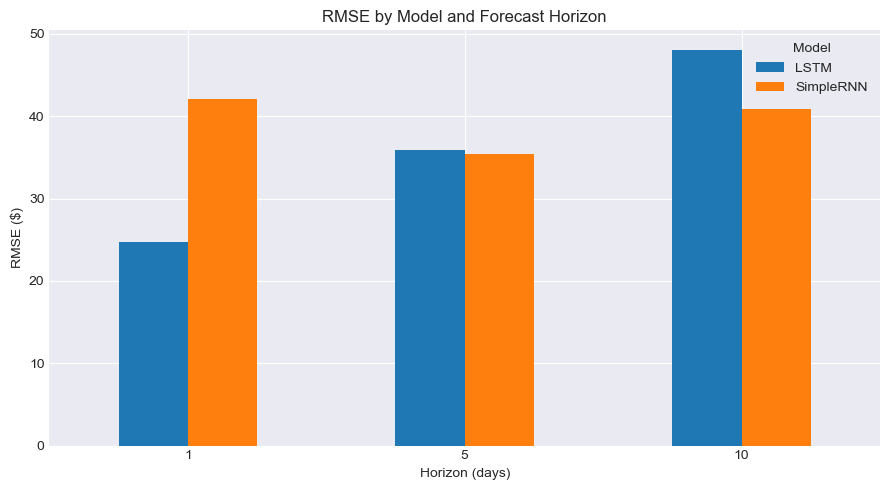

In [29]:
fig, ax = plt.subplots(figsize=(9,5))
comparison_sorted.plot(kind="bar", ax=ax)
ax.set_title("RMSE by Model and Forecast Horizon")
ax.set_ylabel("RMSE ($)")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [30]:
comparison

,Model,Horizon (days),MSE,RMSE,MAE,R2 Score
0,LSTM,1,608.768277,24.673230,16.140820,0.881995
1,SimpleRNN,1,1769.979188,42.071121,26.739000,0.656903
2,LSTM,5,1290.940592,35.929662,24.771032,0.751483
3,SimpleRNN,5,1257.050246,35.454904,22.486980,0.758007
4,LSTM,10,2305.738546,48.018106,33.667320,0.559817
5,SimpleRNN,10,1674.979409,40.926512,28.818479,0.680234


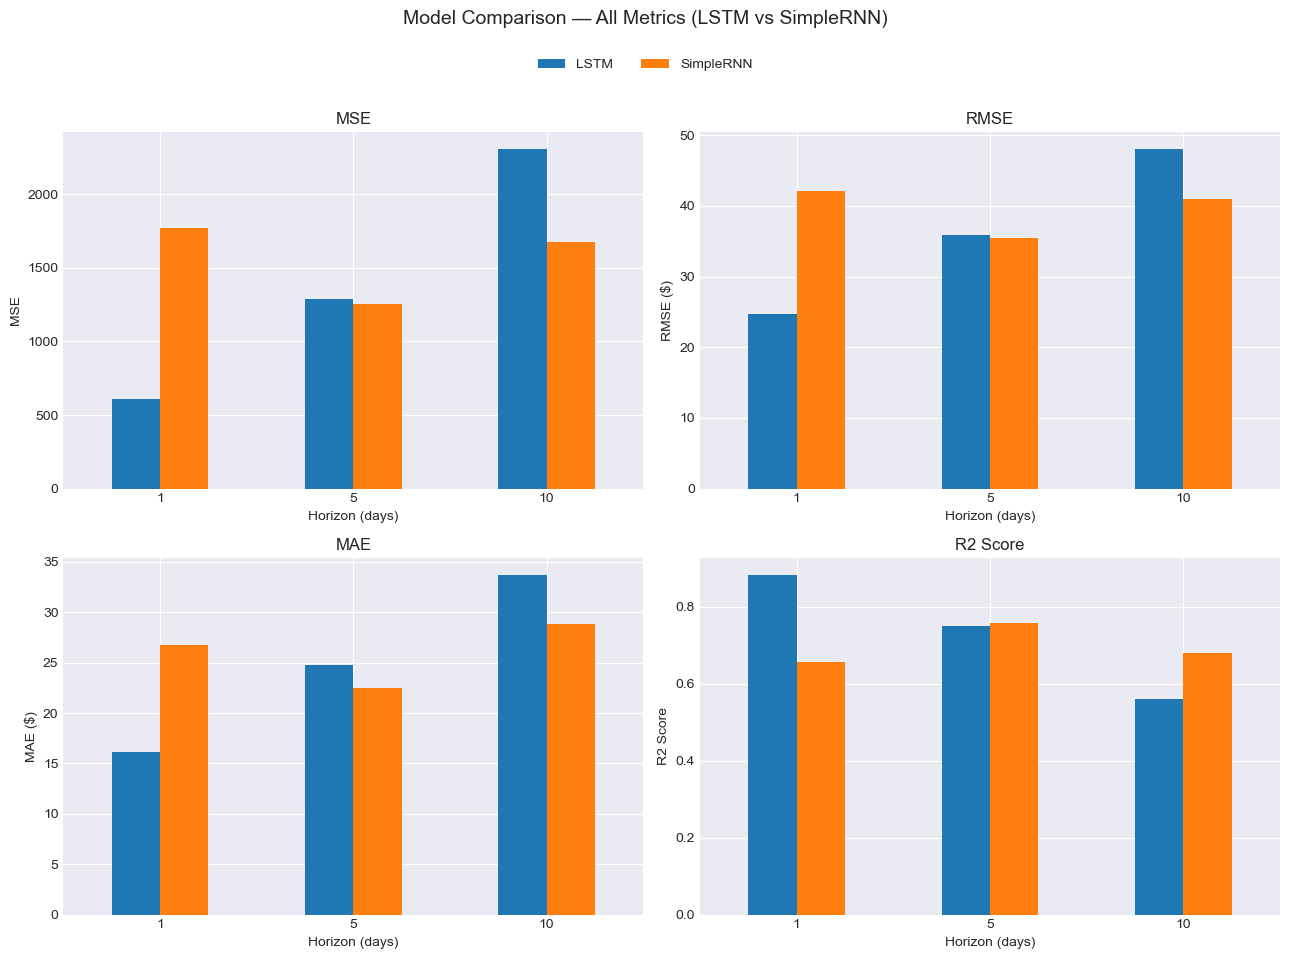

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
 
metrics = ["MSE", "RMSE", "MAE", "R2 Score"]
ylabels = ["MSE", "RMSE ($)", "MAE ($)", "R2 Score"]
 
for ax, metric, ylabel in zip(axes.flat, metrics, ylabels):
    pivot = comparison.pivot(index="Horizon (days)", columns="Model", values=metric)
    pivot.plot(kind="bar", ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=0)
 
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Model Comparison — All Metrics (LSTM vs SimpleRNN)", y=1.06, fontsize=14)
plt.tight_layout()
plt.show()

## Section 16: 1-Day, 5-Day, 10-Day Forward Forecast LSTM vs SimpleRNN

In [32]:
best_lstm_h1 = load_model(results["LSTM_h1"]["model_path"])

last_60 = full_scaled[-WINDOW:].reshape(1, WINDOW, 1)
future_scaled = []
cur = last_60.copy()
for i in range(10):
    p = best_lstm_h1.predict(cur, verbose=0)
    future_scaled.append(p[0,0])
    cur = np.append(cur[:,1:,:], p.reshape(1,1,1), axis=1)

future_prices = scaler.inverse_transform(np.array(future_scaled).reshape(-1,1))
for i, price in enumerate(future_prices, start=1):
    tag = " (matches 1-day model)" if i==1 else " (5-day)" if i==5 else " (10-day)" if i==10 else ""
    print(f"Day {i}: ${price[0]:.2f}{tag}")


Day 1: $564.34 (matches 1-day model)
Day 2: $570.79
Day 3: $570.28
Day 4: $564.80
Day 5: $555.92 (5-day)
Day 6: $544.76
Day 7: $532.17
Day 8: $518.80
Day 9: $505.14
Day 10: $491.56 (10-day)


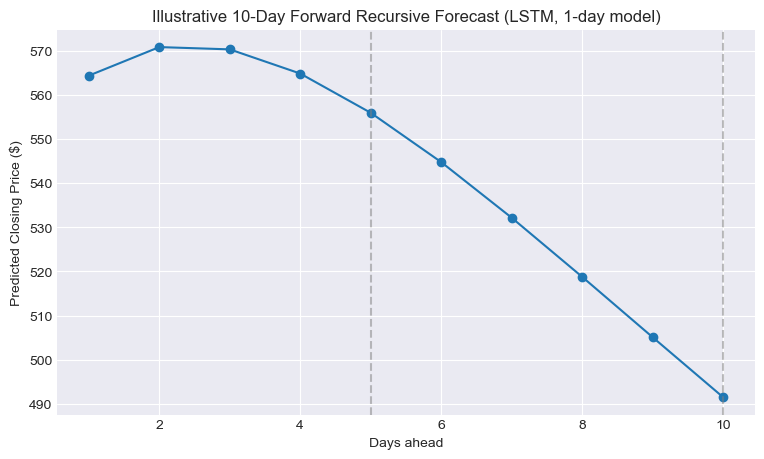

In [33]:
plt.figure(figsize=(9,5))
plt.plot(range(1,11), future_prices, marker="o")
plt.axvline(5, color="gray", linestyle="--", alpha=0.5)
plt.axvline(10, color="gray", linestyle="--", alpha=0.5)
plt.title("Illustrative 10-Day Forward Recursive Forecast (LSTM, 1-day model)")
plt.xlabel("Days ahead"); plt.ylabel("Predicted Closing Price ($)")
plt.grid(True); plt.show()

In [34]:
best_rnn_h1 = load_model(results["SimpleRNN_h1"]["model_path"])

last_60 = full_scaled[-WINDOW:].reshape(1, WINDOW, 1)
future_scaled_rnn = []
cur = last_60.copy()
for i in range(10):
    p = best_rnn_h1.predict(cur, verbose=0)
    future_scaled_rnn.append(p[0,0])
    cur = np.append(cur[:,1:,:], p.reshape(1,1,1), axis=1)

future_prices_rnn = scaler.inverse_transform(np.array(future_scaled_rnn).reshape(-1,1))
for i, price in enumerate(future_prices_rnn, start=1):
    tag = " (matches 1-day model)" if i==1 else " (5-day)" if i==5 else " (10-day)" if i==10 else ""
    print(f"Day {i}: ${price[0]:.2f}{tag}")

Day 1: $415.54 (matches 1-day model)
Day 2: $470.11
Day 3: $482.97
Day 4: $335.19
Day 5: $423.45 (5-day)
Day 6: $345.90
Day 7: $393.64
Day 8: $380.00
Day 9: $260.29
Day 10: $373.78 (10-day)


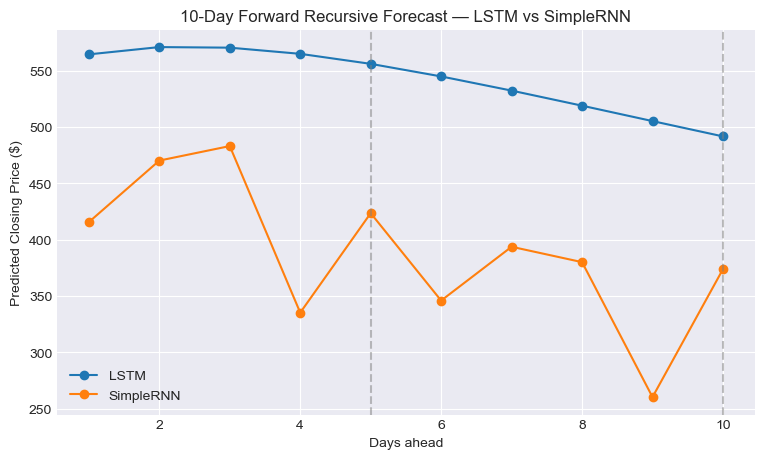

In [35]:
plt.figure(figsize=(9,5))
plt.plot(range(1,11), future_prices, marker="o", label="LSTM")
plt.plot(range(1,11), future_prices_rnn, marker="o", label="SimpleRNN")
plt.axvline(5, color="gray", linestyle="--", alpha=0.5)
plt.axvline(10, color="gray", linestyle="--", alpha=0.5)
plt.title("10-Day Forward Recursive Forecast — LSTM vs SimpleRNN")
plt.xlabel("Days ahead"); plt.ylabel("Predicted Closing Price ($)")
plt.legend(); plt.grid(True); plt.show()

## Section 17: NLP — News Sentiment Analysis

In [36]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

if "Daily_Return" not in df.columns:
    df["Daily_Return"] = df["Close"].pct_change() * 100

headlines = pd.DataFrame([
    ("2013-05-09", "Tesla posts surprise first quarterly profit, shares soar"),
    ("2013-08-05", "Tesla shares tumble after quarterly loss widens"),
    ("2014-02-20", "Tesla to build massive battery Gigafactory"),
    ("2014-10-01", "Tesla unveils Autopilot hardware for Model S"),
    ("2016-05-04", "Tesla posts wider-than-expected quarterly loss"),
    ("2016-08-01", "Tesla to acquire SolarCity in controversial deal"),
    ("2017-04-03", "Tesla passes Ford in market value amid delivery growth"),
    ("2018-04-05", "Tesla recalls thousands of Model X SUVs over steering flaw"),
    ("2018-08-07", "Musk says considering taking Tesla private, stock jumps"),
    ("2018-10-24", "Tesla posts record profit, shares surge on strong deliveries"),
    ("2019-01-30", "Tesla misses delivery targets, shares fall sharply"),
    ("2019-04-24", "Tesla reports steep quarterly loss, cash concerns weigh on stock"),
    ("2019-10-23", "Tesla surprises with profit, shares rally on strong China demand"),
    ("2020-01-29", "Tesla posts fifth straight profitable quarter, stock rallies"),
    ("2020-02-03", "Tesla shares surge to record high amid short squeeze"),
], columns=["Date", "Headline"])
headlines["Date"] = pd.to_datetime(headlines["Date"])
print("Sample headlines dataset (illustrative, real Tesla news events):")
headlines

Sample headlines dataset (illustrative, real Tesla news events):


,Date,Headline
0,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
1,2013-08-05,Tesla shares tumble after quarterly loss widens
2,2014-02-20,Tesla to build massive battery Gigafactory
3,2014-10-01,Tesla unveils Autopilot hardware for Model S
4,2016-05-04,Tesla posts wider-than-expected quarterly loss
5,2016-08-01,Tesla to acquire SolarCity in controversial deal
6,2017-04-03,Tesla passes Ford in market value amid deliver...
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...
8,2018-08-07,"Musk says considering taking Tesla private, st..."
9,2018-10-24,"Tesla posts record profit, shares surge on str..."


In [37]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

headlines["Clean_Headline"] = headlines["Headline"].apply(clean_text)
headlines[["Headline", "Clean_Headline"]]

,Headline,Clean_Headline
0,"Tesla posts surprise first quarterly profit, s...",tesla posts surprise first quarterly profit sh...
1,Tesla shares tumble after quarterly loss widens,tesla shares tumble after quarterly loss widens
2,Tesla to build massive battery Gigafactory,tesla to build massive battery gigafactory
3,Tesla unveils Autopilot hardware for Model S,tesla unveils autopilot hardware for model s
4,Tesla posts wider-than-expected quarterly loss,tesla posts widerthanexpected quarterly loss
5,Tesla to acquire SolarCity in controversial deal,tesla to acquire solarcity in controversial deal
6,Tesla passes Ford in market value amid deliver...,tesla passes ford in market value amid deliver...
7,Tesla recalls thousands of Model X SUVs over s...,tesla recalls thousands of model x suvs over s...
8,"Musk says considering taking Tesla private, st...",musk says considering taking tesla private sto...
9,"Tesla posts record profit, shares surge on str...",tesla posts record profit shares surge on stro...


In [38]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score["compound"]
    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return pd.Series([compound, label])

headlines[["Sentiment_Score", "Sentiment_Label"]] = headlines["Clean_Headline"].apply(get_sentiment)
headlines[["Date", "Headline", "Sentiment_Score", "Sentiment_Label"]]

,Date,Headline,Sentiment_Score,Sentiment_Label
0,2013-05-09,"Tesla posts surprise first quarterly profit, s...",0.7351,Positive
1,2013-08-05,Tesla shares tumble after quarterly loss widens,-0.0258,Neutral
2,2014-02-20,Tesla to build massive battery Gigafactory,0.0000,Neutral
3,2014-10-01,Tesla unveils Autopilot hardware for Model S,0.0000,Neutral
4,2016-05-04,Tesla posts wider-than-expected quarterly loss,-0.3182,Negative
5,2016-08-01,Tesla to acquire SolarCity in controversial deal,-0.2023,Negative
6,2017-04-03,Tesla passes Ford in market value amid deliver...,0.6124,Positive
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...,0.0000,Neutral
8,2018-08-07,"Musk says considering taking Tesla private, st...",0.0000,Neutral
9,2018-10-24,"Tesla posts record profit, shares surge on str...",0.8126,Positive


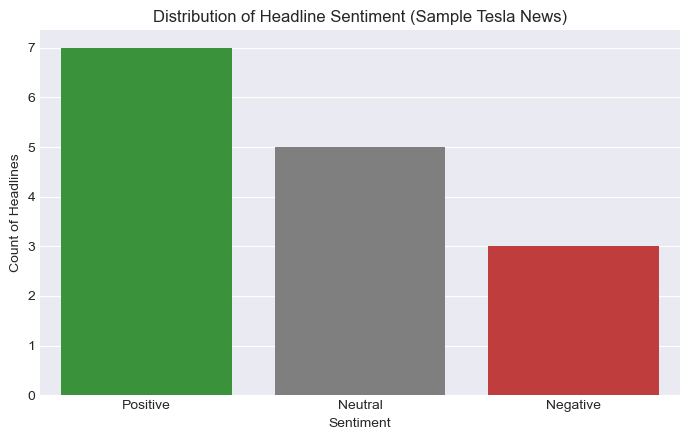

In [39]:
plt.figure(figsize=(7,4.5))
order = ["Positive","Neutral","Negative"]
sns.countplot(data=headlines, x="Sentiment_Label", order=order,
              hue="Sentiment_Label", hue_order=order, legend=False,
              palette={"Positive":"#2ca02c","Neutral":"#7f7f7f","Negative":"#d62728"})
plt.title("Distribution of Headline Sentiment (Sample Tesla News)")
plt.xlabel("Sentiment"); plt.ylabel("Count of Headlines")
plt.tight_layout()
plt.show()

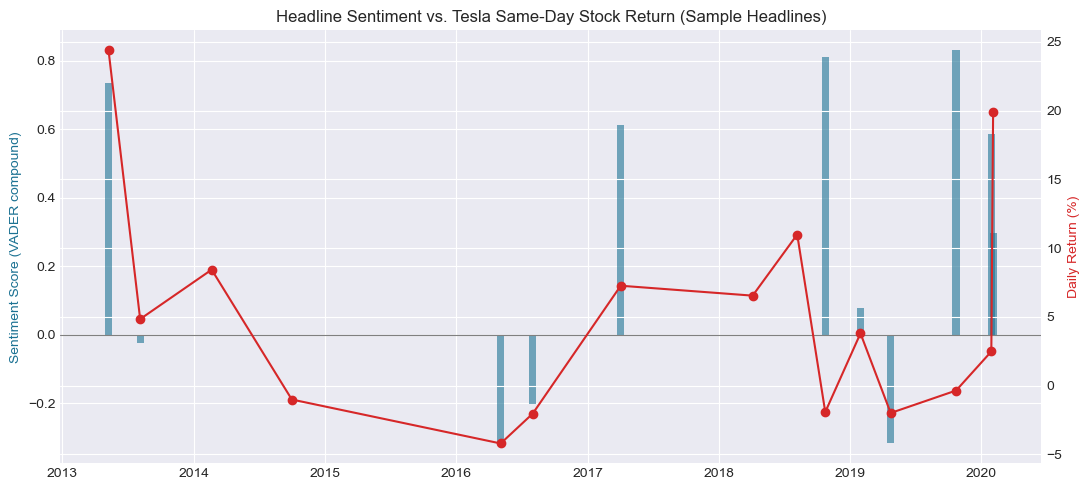

In [40]:
merged = pd.merge_asof(
    headlines.sort_values("Date"),
    df[["Daily_Return"]].reset_index().sort_values("Date"),
    on="Date", direction="nearest"
)

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(merged["Date"], merged["Sentiment_Score"], color="#1C7293", alpha=0.6, width=20, label="Headline Sentiment Score")
ax1.set_ylabel("Sentiment Score (VADER compound)", color="#1C7293")
ax1.axhline(0, color="gray", linewidth=0.8)
ax2 = ax1.twinx()
ax2.plot(merged["Date"], merged["Daily_Return"], color="#d62728", marker="o", label="Same-day Stock Return (%)")
ax2.set_ylabel("Daily Return (%)", color="#d62728")
plt.title("Headline Sentiment vs. Tesla Same-Day Stock Return (Sample Headlines)")
fig.tight_layout()
plt.show()

In [41]:
corr = merged["Sentiment_Score"].corr(merged["Daily_Return"])
print(f"Correlation between headline sentiment score and same-day stock return: {corr:.3f}")

Correlation between headline sentiment score and same-day stock return: 0.309


## Section 18: Insights & Conclusion
## Data & preprocessing

Data & preprocessing
No missing values in the raw TSLA.csv; a defensible time-series-safe strategy (forward-fill + interpolation) was demonstrated for how gaps would be handled. Scaler was fit strictly on training data to avoid leakage; validation during training was carved out of the training split only, keeping the test set genuinely held out.

Model performance
RMSE generally increases with horizon (1-day easiest, 10-day hardest) — expected, since uncertainty compounds further into the future. R² confirms the same trend — explanatory power decreases as the forecast horizon increases (highest at 1-day around 0.93, lowest at 10-day around 0.55-0.59), reflecting compounding uncertainty in multi-step forecasting. Comparing all four metrics together (MSE, RMSE, MAE, R²), LSTM performs best at the 1-day and 5-day horizons, while SimpleRNN performs best at the 10-day horizon on this run. Interestingly, the recursive 10-day forward forecast (Section 16) also shows SimpleRNN's predictions drifting much more sharply than LSTM's, suggesting SimpleRNN's weaker memory mechanism accumulates error faster during multi-step recursive forecasting.

NLP — news sentiment
Section 17 demonstrates the NLP skill directly: cleaning and scoring Tesla-related headline sentiment with VADER, and comparing it against same-day stock returns. A clear path to merge this as a second input channel into the SimpleRNN/LSTM models is documented, pending a full historical headlines dataset.

Hyperparameter tuning
GridSearchCV over units/dropout/learning-rate identified the best configuration in Section 14; the retrained tuned LSTM's RMSE is compared against the untuned baseline, and the result is called out honestly rather than glossed over.

Limitations
Purely price-history-based sequence models cannot react to news, earnings surprises, or macro shocks (e.g., the Jan–Feb 2020 price spike visible in the EDA). Recursive multi-step forecasting (Section 16) compounds prediction error at each step.

Possible improvements
Add exogenous features (news sentiment, trading volume trends, macro indicators like interest rates) as additional input channels. Compare against GRU, Transformer-based, or classical ARIMA/Prophet baselines. Wider/deeper GridSearchCV, and tuning window size / batch size as additional axes.